In [1]:
import os
import time
import glob
import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord
import yaml

import importlib
import numpy as np
import pandas as pd
from math import floor

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

In [2]:
import sys
sys.path.append('observing-program/py')
sys.path.append('grism_sim/py')
os.environ['github_dir']='.'
import grism_dispersion
import footprintutils as fp
import roman_coords_transform as ctrans
from chi2_func import *
from overlap_cal_func import *
import optical_model

code_data_dir = 'observing-program/data/'
rctrans = ctrans.RomanCoordsTransform(file_path=code_data_dir)

In [3]:
optmod = optical_model.RomanOpticalModel()

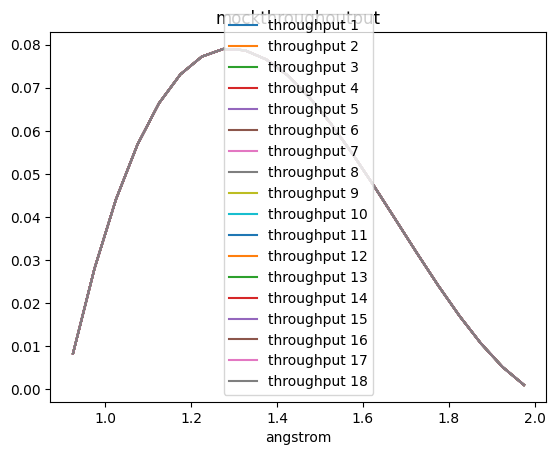

In [4]:
_coeff = optmod._get_beam_trace(2044,2044,1, width=1, order="+1")

_1, _2, _3, _4, master_bins = bin_cut(_coeff) #left edges of bins

def throughput(x):
    coeff = [0.4, -0.9, -2.7, 3.3]
    scale = 1
    terms = [coeff[i]*x**(3-i) for i in range(4)]
    return scale*sum(terms)

def rescale(x):
    return (x - np.min(x)) / np.sum((x - np.min(x)))

lam = np.linspace(-2.5,2,22)
rescaled = rescale(throughput(lam))
master_bin_centers = (master_bins[1] - master_bins[0])/2 + master_bins
throughput_data = np.zeros((18, len(master_bin_centers)))
for i in range(18):

    sca_throughput = rescale(throughput(lam))
    throughput_data[i] = sca_throughput+0.001
    
# throughput_data[17] *= 0.5
# plt.plot(master_bin_centers, throughput_data[5]/throughput_data[2], label = "throughput")
for i in range(18):
    plt.plot(master_bin_centers, throughput_data[i], label = f"throughput {i+1}")
plt.legend()
plt.title("mockthroughoutput")
plt.xlabel("angstrom")
plt.show()

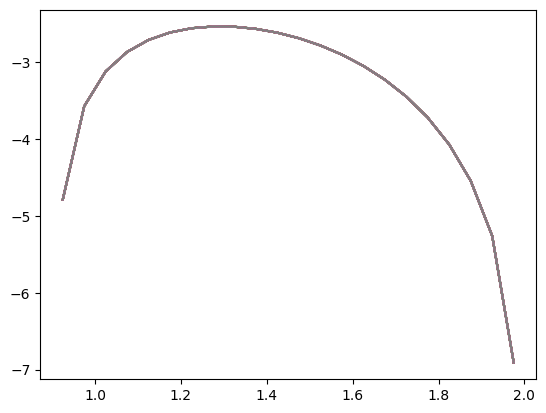

In [5]:
throughput_data = np.log(throughput_data)
for i in range(18):
    plt.plot(master_bin_centers, throughput_data[i], label = f"throughput {i+1}")

array([-4.78975135, -3.57512766, -3.12166064, -2.86845528, -2.71242298,
       -2.61582539, -2.56087159, -2.53803411, -2.54190967, -2.56946749,
       -2.61923431, -2.69091604, -2.78526576, -2.90413386, -3.05070977,
       -3.2300414 , -3.45005942, -3.72368251, -4.07364919, -4.54590821,
       -5.26163127, -6.90775528])

In [6]:
np.sum(throughput_data)/18

np.float64(-75.13651316883222)

In [7]:
ra0 = 0
dec0 = 0
dithstep = 0.125*.2,0.125*.4
ndith = 2
decpa = 0.087
rapa = 0.0
decoffl = [decpa,decpa,-decpa,-decpa]
raoffl = [rapa,rapa/3,-rapa/3,-rapa]
pa_off = 0
pal = [-2.5+pa_off,2.5+pa_off,177.5+pa_off,182.5+pa_off]
pa = pal[0]
decoff = decoffl[0]#decpa/2
raoff = raoffl[0]

pointing_coords = []

survey = 1

if survey == 0:
    pointing_coords.append([ra0+raoff, dec0+decoff, pa])
elif survey == 1:
    for dith in range(0,ndith):
        decoff = decoffl[0]#decpa/2
        raoff = raoffl[0]
        pointing_coords.append([ra0+raoff+dith*dithstep[0], dec0+decoff+dith*dithstep[1], pa])
elif survey == 2:
    for pa,decoff,raoff in zip(pal,decoffl,raoffl):
        pointing_coords.append([ra0+raoff, dec0+decoff, pa])
elif survey == 3:
    for pa,decoff,raoff in zip(pal,decoffl,raoffl):
        for dith in range(0,ndith):
            #decoff = decpa/2
            #if pa > 100:
            #    decoff = -decpa/2
            pointing_coords.append([ra0+raoff+dith*dithstep[0], dec0+decoff+dith*dithstep[1], pa])

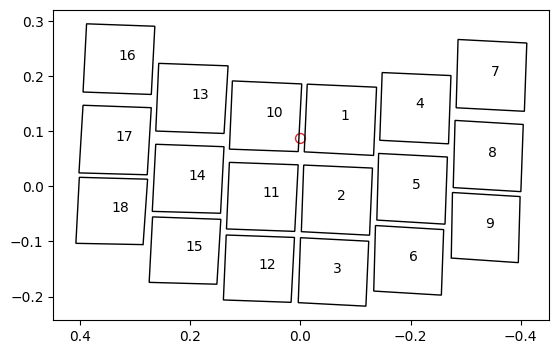

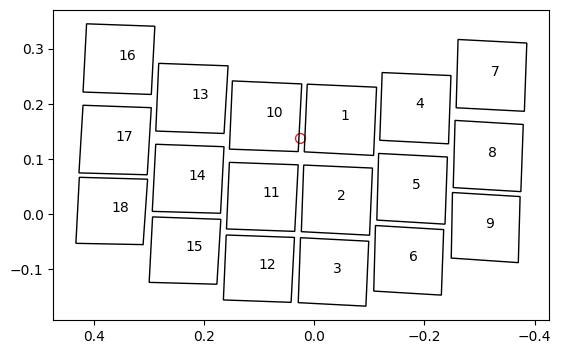

In [8]:
footprints = {}

for i in range(len(pointing_coords)):
  dfoot = rctrans.wfi_sky_pointing(pointing_coords[i][0], pointing_coords[i][1], pointing_coords[i][2], ds9=False, ax=None)
  for detector in range(1,19):
    footprints[detector+i*18] = dfoot[0][detector]

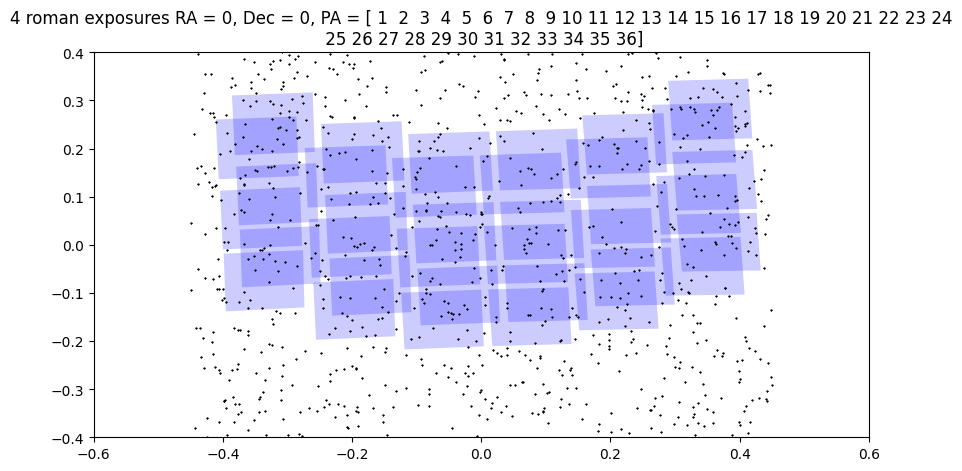

In [9]:
fig, ax = plt.subplots(figsize = (10,5))

##sim parameters
ns = 1000 # initial number of stars
exp = np.arange(len(footprints))+1
Nexp = len(exp)

for footprint in exp:
  data = footprints[footprint]
  corners = data['vertices']
  polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
  
  ax.add_patch(polygon)

plt.title("4 roman exposures RA = 0, Dec = 0, PA = {}".format(exp))

stars_x = (np.random.rand(ns) - 0.5)*0.9
stars_y = (np.random.rand(ns) - 0.5)*0.8

# stars_x = np.linspace(-0.5,0.5, 100)
# stars_x = np.tile(stars_x, 100)
# stars_y = np.linspace(-0.25,0.35,100)
# stars_y = np.sort(np.repeat(stars_y, 100))

plt.xlim(-0.6, 0.6)
plt.ylim(-0.4, 0.4)

plt.plot(stars_x, stars_y, "*", color = "black", markersize = 1)
# plt.gca().invert_xaxis()
# plt.plot(star[0], star[1], "*", color = "black", markersize = 3)
plt.show()

In [10]:
#create lists of paths for exposures

stars = np.zeros((ns,2))
stars[:,0] = stars_x
stars[:,1] = stars_y

select_exposure = {}

for footprint in exp:
  corners = footprints[footprint]['vertices']
  verts = np.concatenate((corners, [corners[0]]))
  path = Path(verts)
  footprints[footprint]['path'] = path
  ondetector = path.contains_points(stars)
  select_exposure[footprint] = ondetector



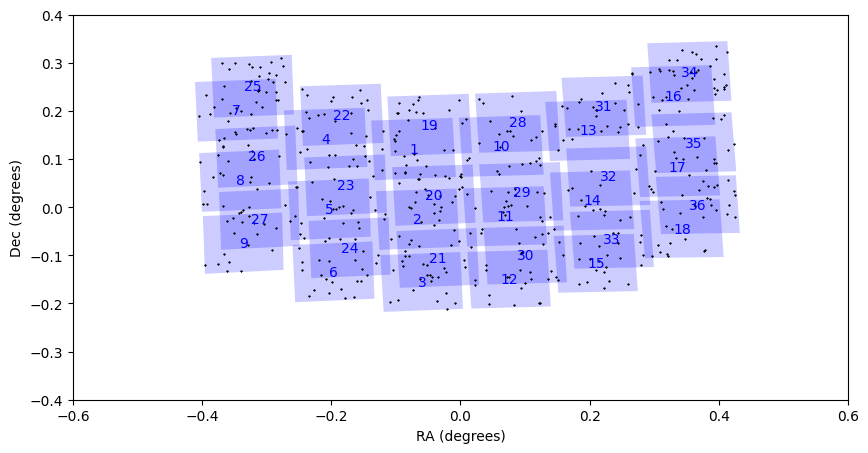

In [11]:
select_observed = np.array([False]*ns)
for footprint in exp:
  select_observed += select_exposure[footprint]
ns_obs = np.sum(select_observed)
stars_obs = stars[select_observed]

select_obs_exposure = {}
for footprint in exp:
  select_obs_exposure[footprint] = select_exposure[footprint][select_observed]

# Create a figure and an axes
fig, ax = plt.subplots(figsize = (10,5))
for footprint in exp:
  corners = footprints[footprint]['vertices']
  polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
  ax.add_patch(polygon)
  # Add the footprint label at the centroid of the polygon
  centroid = np.mean(corners, axis=0)
  ax.text(centroid[0], centroid[1], str(footprint), color='blue', fontsize=10, ha='center', va='center')

plt.plot(stars_obs[:,0], stars_obs[:,1], "*", color = "black", markersize = 1)
plt.xlim(-0.6, 0.6)
plt.ylim(-0.4, 0.4)
# Display the plot
plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.show()

In [12]:
#im gonna assume an arbitrary sigma k here
np.random.seed(17)
sigk = 0.1
sig_star = 0.5

true_k = np.random.normal(0,sigk**2,len(exp))
true_k -= np.mean(true_k)

# true_k2 = np.random.normal(0,sigk**2,len(exp))
# true_k2 -= np.mean(true_k2)
# true_k2 += 2
# true_k = np.astype(np.arange(len(exp))**2, "float64")
# true_k /= np.max(true_k)  # Normalize to the maximum value


# true_k += 2

# true_brightness = np.random.normal(1.0,sig_star**2,len(stars_obs))
true_brightness = np.ones(len(stars_obs))  # Assuming a constant brightness for simplicity
sig_ij = 0.01
sig_lam = 0.1

# true_k -= np.mean(true_k)
# true_k += 8
Nstars  = stars_obs.shape[0] #observed number of stars

exists_in_exp = np.zeros((Nexp, Nstars), dtype=bool)

for i in exp:
    mask = np.zeros(Nstars, dtype=bool) #initialise all false
        #loop through every detector (theres probably a faster way to do this)
        #do path contains points for each exposure
    path = footprints[i]['path']
    mask |= path.contains_points(stars_obs)      
    exists_in_exp[i-1] = mask


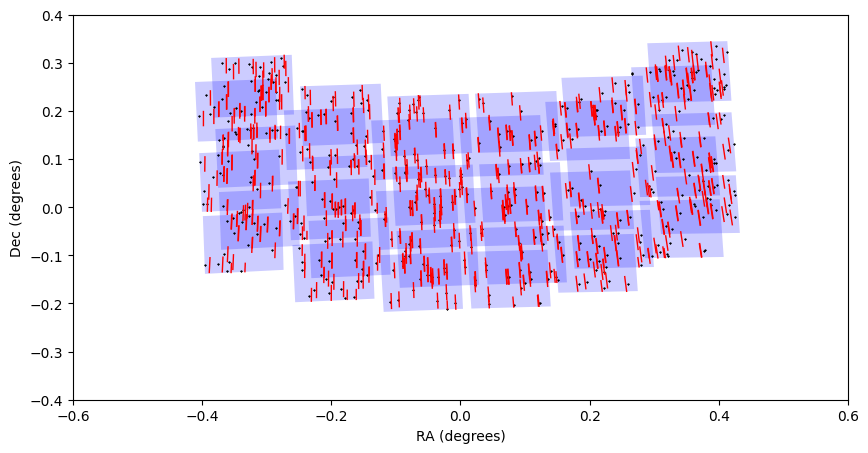

In [13]:
fig, ax = plt.subplots(figsize = (10,5))
for footprint in exp:
    corners = footprints[footprint]['vertices']
    polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
    ax.add_patch(polygon)
    # Add the footprint label at the centroid of the polygon
    centroid = np.mean(corners, axis=0)
    # ax.text(centroid[0], centroid[1], str(footprint), color='black', fontsize=10, ha='center', va='center')

plt.plot(stars_obs[:,0], stars_obs[:,1], "*", color = "black", markersize = 1)
plt.xlim(-0.6, 0.6)
plt.ylim(-0.4, 0.4)

# plt.xlim(-0.45, -0.30)
# plt.ylim(-0.08, 0.08)

"""apply grism information to stars"""

wvl_bins = len(master_bins)
stars_wvl = {key: val for key, val in zip(master_bins, [[] for _ in range(wvl_bins)])}

star_colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'cyan']
starids = np.arange(len(stars_obs))

for i in range(len(exp)):
    star_mask = exists_in_exp[i]
    stars_in_exp = stars_obs[star_mask]
    stars_in_exp_ids = starids[star_mask]
    stars_in_exp_true_bright = true_brightness[star_mask]
    for star, id, bright in zip(stars_in_exp, stars_in_exp_ids, stars_in_exp_true_bright):
        fid = (i + 1)
        scaid = fid - 18 * np.floor((fid) / 18)  # Adjust fiducial ID to be in range 1-18
        if scaid == 0:
            scaid = 18
        det_coord = quad_to_square_transform(star[0], star[1], footprints[fid]['vertices'], src_size=4088)
        det_pixl = np.floor(det_coord)
        coeff = optmod._get_beam_trace(det_pixl[0], det_pixl[1], scaid, width=1, order="+1")
        x_binned, y_binned, colors, select_on_detector, bins = bin_cut(coeff)
        px, py = square_to_quad_transform(x_binned, y_binned, footprints[fid]['vertices'], src_size=4088)
        
        temp_dict = {key: val for key, val in [(bin, coord) for bin, coord in zip(bins, np.array([px,py]).T)]}
        plt.plot(px,py, color="red", lw = 1)
        for b,x,y in zip(bins, px, py):
            stars_wvl[b].append((fid, id, x, y))

for b in stars_wvl.keys():
    stars_wvl[b] = np.array(stars_wvl[b])

plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.show()

In [54]:
throughput = throughput_data[0] 


In [56]:
lambda_bins = np.array([k for k in stars_wvl.keys()]) 
Nstars = len(stars_obs)
Nexp = len(exp)
row = 0
m_ijlam = np.zeros((Nexp, Nstars, len(lambda_bins)), dtype=float)  # Initialize m_ijlam with zeros
# throughput = np.random.normal(0, 0.01, size = (Nexp, len(lambda_bins)))
for lam_id, lam in enumerate(stars_wvl.keys()):
    fids = stars_wvl[lam][:,0]
    starids = stars_wvl[lam][:,1]

    exists_in_exp = np.zeros((Nexp, Nstars), dtype=bool)

    for f, s in zip(fids, starids):
        exists_in_exp[int(f-1),int(s)] = True
    
    m_ij = [true_brightness for _ in range(Nexp)]
    m_ij = np.array(m_ij)
    m_ij = np.where(exists_in_exp, m_ij - throughput[lam_id], 0.0)
    m_ijlam[:,:,lam_id] = m_ij  # Store the brightness values for each wavelength bin  
    # select_overlaps, Nl = find_overlaps(exp, exists_in_exp, Nstars)
    # print(Nl)
    # Nstarl = np.array([len(stars_obs[select_overlaps[l]]) for l in range(Nl)])

    # # Stack overlap masks: shape (Nl, Nstars)
    # overlap_mask = np.vstack(select_overlaps)  # shape (Nl, Nstars)
    # # insert an i axis to overlap_mask and a l axis to m_ij
    # masked = np.where(overlap_mask[None, :, :], m_ij[:, None, :], np.nan)  # shape (Nexp, Nl, Nstars)
    # # Compute mean over stars axis (axis=2), ignoring NaNs
    # m_il = np.nanmean(masked, axis=2)  # shape (Nexp, Nl)
m_ijlam = np.array(m_ijlam)
# nonzero_ijlam = (m_ijlam != 0.0)
print(m_ijlam.shape)
# print(np.sum(m_ijlam, axis = 0).shape)
# count_nonzero = np.count_nonzero(m_ijlam, axis=0)
# jj = count_nonzero == 0
# denom = count_nonzero+jj

(36, 508, 22)


In [57]:
def chi2J_lam(klam, m_lamj, sig_j, sig_klam):
    """
    klam:   shape (Nlam,)
    m_lamj: shape (Nlam, Nj)
    sig_j: scalar
    sig_k: scalar
    """
    Nlam, Nj = m_lamj.shape

    ######
    ###### compute chi2
    ######

    nonzero_mask = (m_lamj != 0)                # shape (Nd, Nj)

    mc_lamj = np.where(nonzero_mask, m_lamj + klam[:, None], 0.0) #mask selects non-zero entries, adds ki by column and zeros the correct entries
    counts = nonzero_mask.sum(axis=0)         # shape (Nj,)
    # avoid division-by-zero if some column is all zeros
    counts = np.where(counts == 0, 1, counts)
    col_sums = mc_lamj.sum(axis=0)    # shape (Nj,)
    mc_j = col_sums / counts          # shape (Nj,)

    res = mc_lamj - mc_j[None, :]
    # zero out invalid positions
    res *= nonzero_mask

    chi2 = np.sum(res**2 / sig_j**2) + np.sum((klam)**2) / sig_klam**2

    ######
    ###### compute gradient
    ######

    g_term1 = (-2/Nlam)*np.sum(res**2 / sig_j**2)
    g_term2 = 2*np.sum(res, axis = 1) / sig_j**2
    g_term3 = 2*(klam)/sig_klam**2

    gradient = g_term1 + g_term2 + g_term3

    # return chi2 and gradient
    return chi2, gradient

In [58]:
m_jlam = m_ijlam[0]
m_lamj = m_jlam.T  # Transpose to get shape (Nlam, Nstars)

In [60]:
k_test = np.zeros(len(lambda_bins))  # Initialize k_test with zeros

start = time.time()
# cali = run_calibration(stars_wvl, exp, stars_obs, sig_ij, sigk, true_brightness, true_k, throughput_data)
resJ_vec = minimize(chi2J_lam, k_test, method='L-BFGS-B', args=(m_lamj, sig_ij, sigk), jac = True)
print(time.time() - start)

out_k = resJ_vec.x

0.010499954223632812


In [61]:
out_k

array([-1.37310631, -0.15919676,  0.29400364,  0.54707678,  0.70304257,
        0.7996112 ,  0.85455974,  0.87738636,  0.8735363 ,  0.84599099,
        0.79624679,  0.72462188,  0.63031319,  0.51149676,  0.36498458,
        0.18573765, -0.03418042, -0.3076792 , -0.65748689, -1.12953136,
       -1.84492927, -3.49030546])

ValueError: x and y must have same first dimension, but have shapes (22,) and (1,)

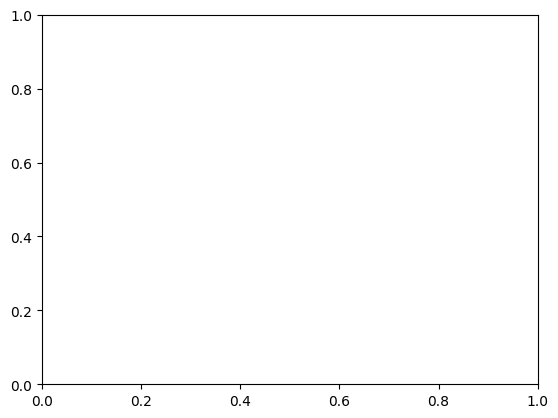

In [63]:
plt.plot(out_k, throughput[0]-np.mean(throughput[0]), '.')
plt.plot(np.linspace(-2.5,3,100), np.linspace(-2.5,3,100), '--', color = "black")
plt.xlim(np.min(out_k), np.max(out_k))
plt.ylim(np.min(out_k), np.max(out_k))


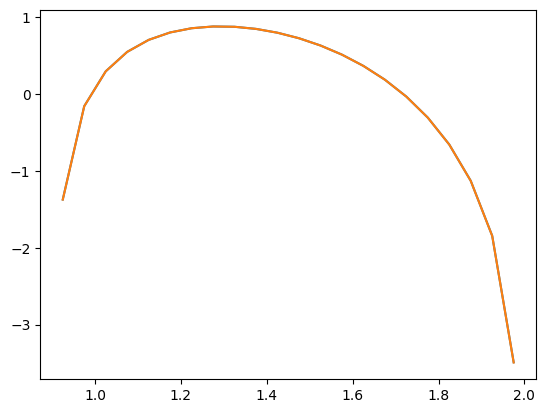

In [68]:
plt.plot(master_bin_centers, out_k)
plt.plot(master_bin_centers, throughput- np.mean(throughput), label = "throughput")

In [ ]:
np.mean(((out_k-true_k)/true_k)*100)

np.float64(0.22567525164379243)

In [ ]:
fract_err = ((out_k-true_k)/true_k)*100
np.sum(fract_err < 2)/ len(fract_err)

np.float64(0.8333333333333334)

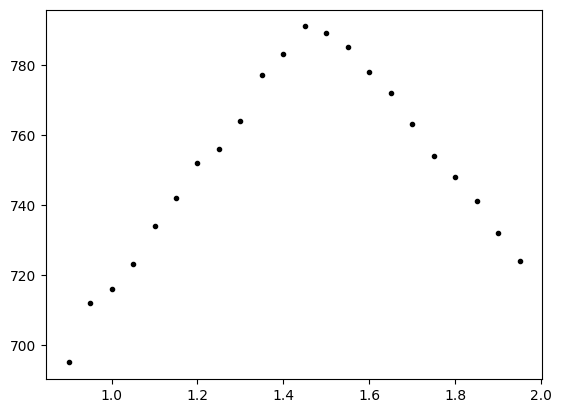

In [ ]:
for b in stars_wvl.keys():
    plt.plot(b, len(stars_wvl[b]), "k.")

In [ ]:
throughput_data[:,0].shape

(18,)